# Policy Gradient Methods

Task:

Part 1: Implement REINFORCE and REINFORCE with baseline for Gymnasium’s CartPole-v1 (discrete actions, Box observation space). Use PyTorch to build a policy network with 2-3 hidden layers using nn.Module. The policy network should output action logits, convert to probabilities via F.softmax(), and sample actions using torch.distributions.Categorical. Implement the baseline as a separate state-value network.

Your implementation should: (1) collect complete episodes by converting NumPy observations to PyTorch tensors, (2) compute returns G_t for each time step, (3) compute log probabilities using dist.log_prob(action), (4) compute policy loss as -log_prob * (G_t - baseline), (5) call loss.backward() for automatic gradient computation, (6) update networks using a PyTorch optimizer like Adam. Convert between Gymnasium’s NumPy observations and PyTorch tensors appropriately.

Plot learning curves comparing: (1) REINFORCE without baseline, (2) REINFORCE with baseline—show both mean return and variance across episodes. Use multiple random seeds and show confidence intervals. Use torch.save() to checkpoint your trained models.

In [3]:
import numpy as np
import gymnasium as gym
from collections import defaultdict
import itertools
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# Environment Inspection

In [4]:
# Environment Inspection Function
def inspect_environment(env_name):

    env = gym.make(env_name)

    print(f"\nEnvironment: {env_name}")
    print("-"*40)

    obs_space = env.observation_space
    act_space = env.action_space

    print("Observation Space:", obs_space)
    print("Action Space:", act_space)

    # Inspecting space details
    if isinstance(obs_space, gym.spaces.Discrete):
        print("Observation Type: Discrete")
        print("Number of states:", obs_space.n)

    elif isinstance(obs_space, gym.spaces.Box):
        print("Observation Type: Continuous")
        print("Shape:", obs_space.shape)
        print("Bounds:", obs_space.low, obs_space.high)

    # Getting Action space details
    if isinstance(act_space, gym.spaces.Discrete):
        print("Action Type: Discrete")
        print("Number of actions:", act_space.n)

    elif isinstance(act_space, gym.spaces.Box):
        print("Action Type: Continuous")
        print("Shape:", act_space.shape)
        print("Bounds:", act_space.low, act_space.high)

    env.close()

In [5]:
# Inspecting CartPole-v1 Environment
inspect_environment("CartPole-v1")


Environment: CartPole-v1
----------------------------------------
Observation Space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action Space: Discrete(2)
Observation Type: Continuous
Shape: (4,)
Bounds: [-4.8               -inf -0.41887903        -inf] [4.8               inf 0.41887903        inf]
Action Type: Discrete
Number of actions: 2


# Policy Network

In [6]:
# Policy Network Class Definition
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )

    def forward(self, state):
        logits = self.net(state)
        return logits

    def get_action(self, state):
        logits = self.forward(state)
        probs = F.softmax(logits, dim=-1)
        dist = torch.distributions.Categorical(probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob


## Baseline Value Network


In [7]:
# Baeline Value Network Class Definition
class ValueNetwork(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state):
        return self.net(state).squeeze(-1)


# Episode Collection

In [8]:
# Episode collection function
def collect_episode(env, policy):
    states, actions, rewards, log_probs = [], [], [], []

    state, _ = env.reset()
    done = False

    while not done:
        state_tensor = torch.FloatTensor(state)

        action, log_prob = policy.get_action(state_tensor)

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state_tensor)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(log_prob)

        state = next_state

    return states, actions, rewards, log_probs


# Returns (Gt) Computation

In [9]:
# Returns (Gt) Function
def compute_returns(rewards, gamma=0.99):
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return torch.FloatTensor(returns)


# Setups

## REINFORCE (No Baseline)

In [10]:
# Reinforce (No Baseline) Function
def train_reinforce(env, policy, optimizer, episodes=500, gamma=0.99):
    all_returns = []

    for ep in range(episodes):
        states, actions, rewards, log_probs = collect_episode(env, policy)
        returns = compute_returns(rewards, gamma)

        # Normalize returns
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = []
        for log_prob, G in zip(log_probs, returns):
            loss.append(-log_prob * G)

        loss = torch.stack(loss).sum()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        all_returns.append(sum(rewards))

    return all_returns


## REINFORCE with Baseline

In [11]:
# Reinforce with Baseline Function
def train_reinforce_baseline(env, policy, value_net, policy_opt, value_opt,
                             episodes=500, gamma=0.99):
    all_returns = []

    for ep in range(episodes):
        states, actions, rewards, log_probs = collect_episode(env, policy)
        returns = compute_returns(rewards, gamma)

        states_tensor = torch.stack(states)
        values = value_net(states_tensor)

        advantages = returns - values.detach()

        # Policy loss
        policy_loss = []
        for log_prob, adv in zip(log_probs, advantages):
            policy_loss.append(-log_prob * adv)
        policy_loss = torch.stack(policy_loss).sum()

        # Value loss
        value_loss = F.mse_loss(values, returns)

        # Update policy
        policy_opt.zero_grad()
        policy_loss.backward()
        policy_opt.step()

        # Update value network
        value_opt.zero_grad()
        value_loss.backward()
        value_opt.step()

        all_returns.append(sum(rewards))

    return all_returns


### Plots

In [12]:
# Helper Functions
def moving_average(x, window=20):
    return np.convolve(x, np.ones(window)/window, mode='valid')

def moving_variance(x, window=20):
    return np.array([np.var(x[i:i+window]) for i in range(len(x)-window+1)])

In [13]:
# Mean Returns Single Train Leaning Curve
def plot_mean_return_single_train(returns, label="Model", window=20, color=None):

    mean = moving_average(returns, window)
    x = np.arange(len(mean))

    plt.plot(x, mean, label=label, color=color)

    plt.title("Mean Return (Smoothed)")
    plt.xlabel("Episodes")
    plt.ylabel("Return")

    plt.grid(alpha=0.3)

In [14]:
# Variance of Returns Single Train Leaning Curve
def plot_variance_single_train(returns, label="Model", window=20, color=None):

    var = moving_variance(returns, window)
    x = np.arange(len(var))

    plt.plot(x, var, label=label, color=color)

    plt.title("Variance (Rolling)")
    plt.xlabel("Episodes")
    plt.ylabel("Variance")

    plt.grid(alpha=0.3)

# Experiment

## Multi-Seed Experiment Framework

In [15]:
def run_experiment(train_fn, seeds, episodes=500):
    all_runs = []

    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)

        env = gym.make("CartPole-v1")

        state_dim = env.observation_space.shape[0]
        action_dim = env.action_space.n

        policy = PolicyNetwork(state_dim, 128, action_dim)

        if train_fn.__name__ == "train_reinforce":
            optimizer = optim.Adam(policy.parameters(), lr=1e-3)
            returns = train_fn(env, policy, optimizer, episodes)

            # Saving Model
            torch.save({
                "policy_state_dict": policy.state_dict(),
                "seed": seed,
                "returns": returns
            }, f"reinforce_seed_{seed}.pt")

        else:
            value_net = ValueNetwork(state_dim, 128)
            policy_opt = optim.Adam(policy.parameters(), lr=1e-3)
            value_opt = optim.Adam(value_net.parameters(), lr=1e-3)

            returns = train_fn(env, policy, value_net, policy_opt, value_opt, episodes)

            # Saving Model (baseline)
            torch.save({
                "policy_state_dict": policy.state_dict(),
                "value_state_dict": value_net.state_dict(),
                "seed": seed,
                "returns": returns
            }, f"baseline_seed_{seed}.pt")

        all_runs.append(returns)

    return np.array(all_runs)


### Plots

In [16]:
# Learning Curve Plots - Mean Returns
def plot_results(results1, results2, label1="REINFORCE", label2="Baseline"):

    def plot_curve(data, label):
        mean = data.mean(axis=0)
        std = data.std(axis=0)
        x = np.arange(len(mean))

        plt.plot(x, mean, label=label)
        plt.fill_between(x, mean - std, mean + std, alpha=0.2)

    plt.figure(figsize=(10,6))
    plot_curve(results1, label1)
    plot_curve(results2, label2)

    plt.xlabel("Episodes")
    plt.ylabel("Return")
    plt.legend()
    plt.title("Learning Curves - Mean Returns for Multi-seed Experiment")
    plt.show()

In [17]:
# Learning Curve Plots - Variance of Returns
def plot_variance(results1, results2, label1="REINFORCE", label2="Baseline"):

    var1 = results1.var(axis=0)
    var2 = results2.var(axis=0)

    x = np.arange(len(var1))

    plt.figure(figsize=(10,6))
    plt.plot(x, var1, label=f"{label1} Variance")
    plt.plot(x, var2, label=f"{label2} Variance")

    plt.xlabel("Episodes")
    plt.ylabel("Variance of Return")
    plt.title("Learning Curves - Variance of Returns for Multi-seed Experiment")
    plt.legend()
    plt.show()


# Results

## REINFORCE (No Baseline) Experiment

In [18]:
seeds = [0, 1, 2, 3, 4]
episodes = 500

results_reinforce = run_experiment(train_reinforce, seeds, episodes)

### Plots

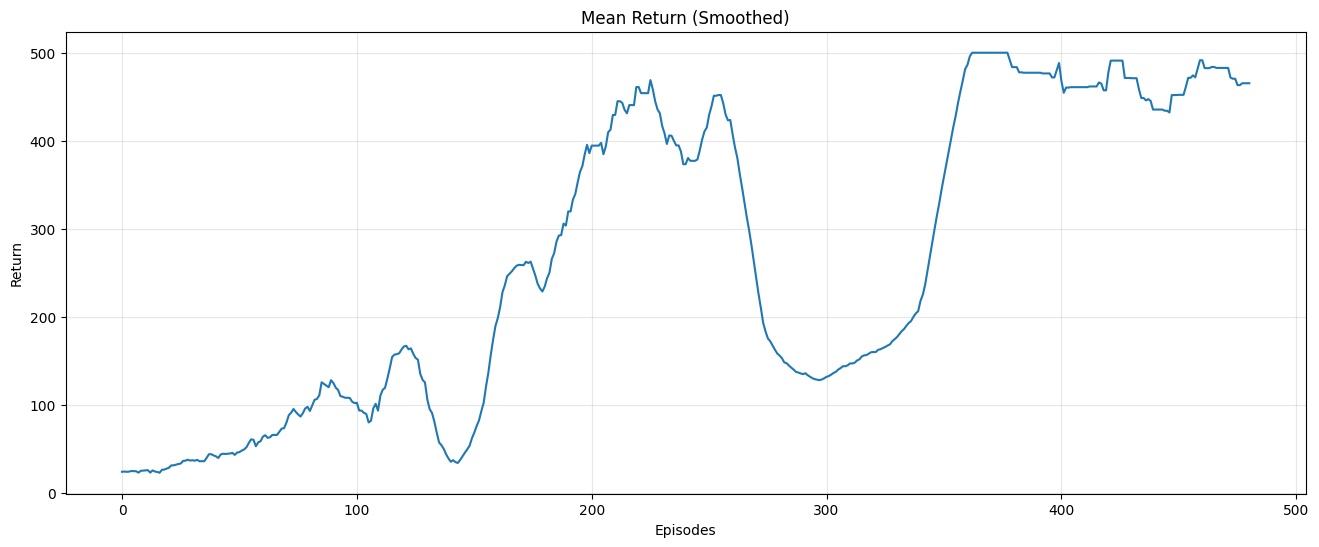

In [29]:
plt.figure(figsize=(16,6))
plot_mean_return_single_train(results_reinforce[0], label="REINFORCE")

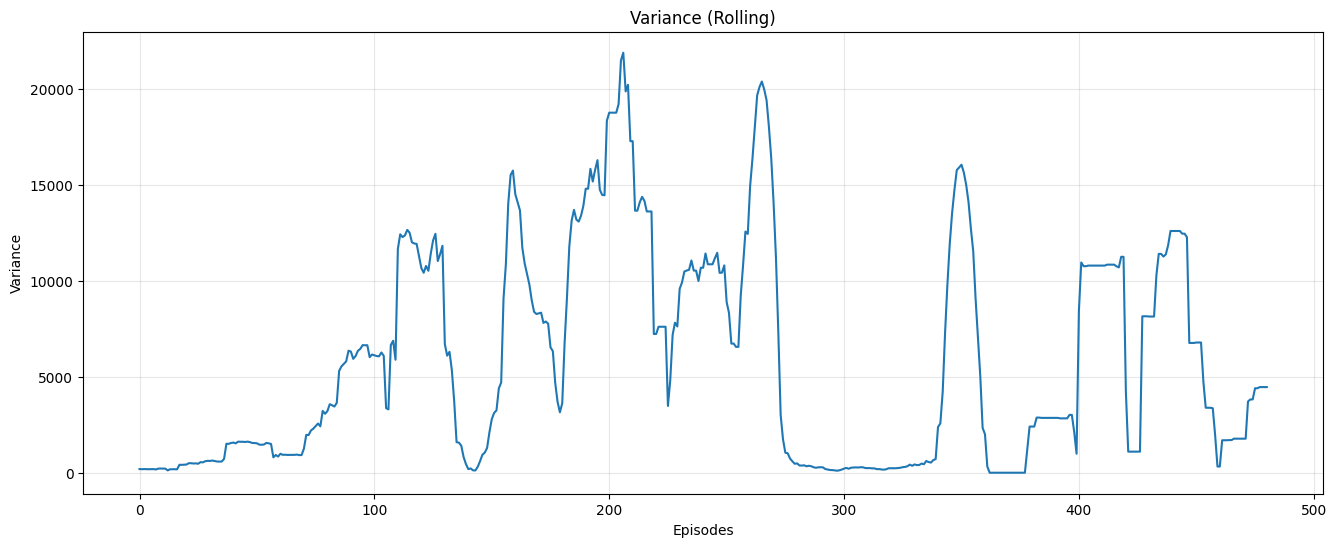

In [30]:
plt.figure(figsize=(16,6))
plot_variance_single_train(results_reinforce[0], label="REINFORCE")

## REINFORCE with Baseline Experiment

In [21]:
seeds = [0, 1, 2, 3, 4]
episodes = 500

results_baseline = run_experiment(train_reinforce_baseline, seeds, episodes)

### Plots

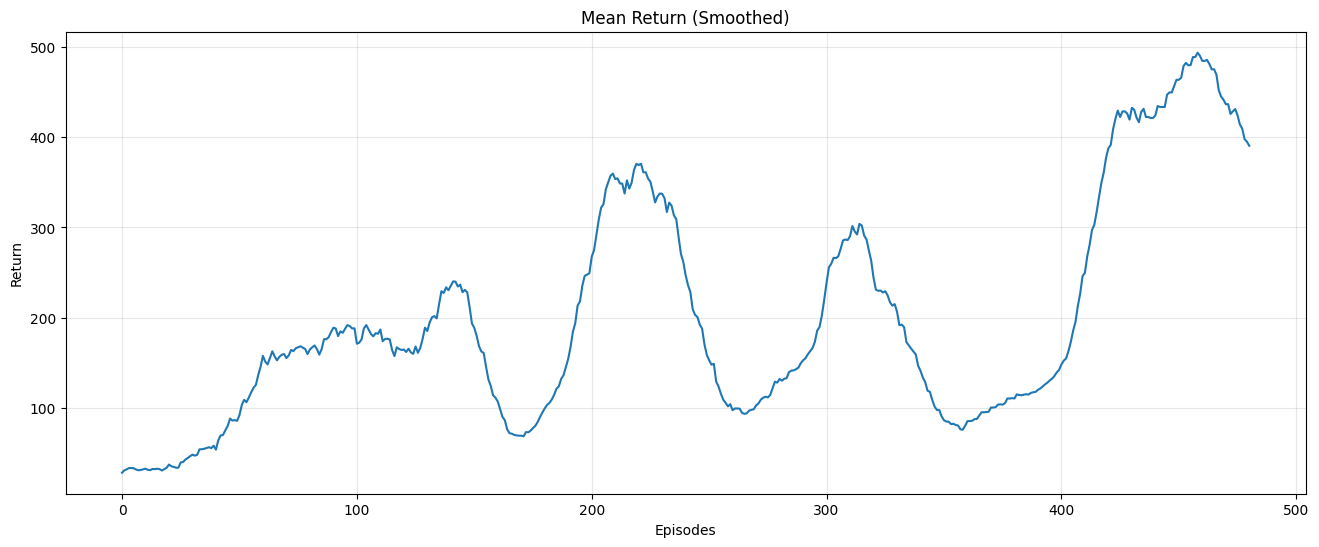

In [31]:
plt.figure(figsize=(16,6))
plot_mean_return_single_train(results_baseline[0], label="REINFORCE")

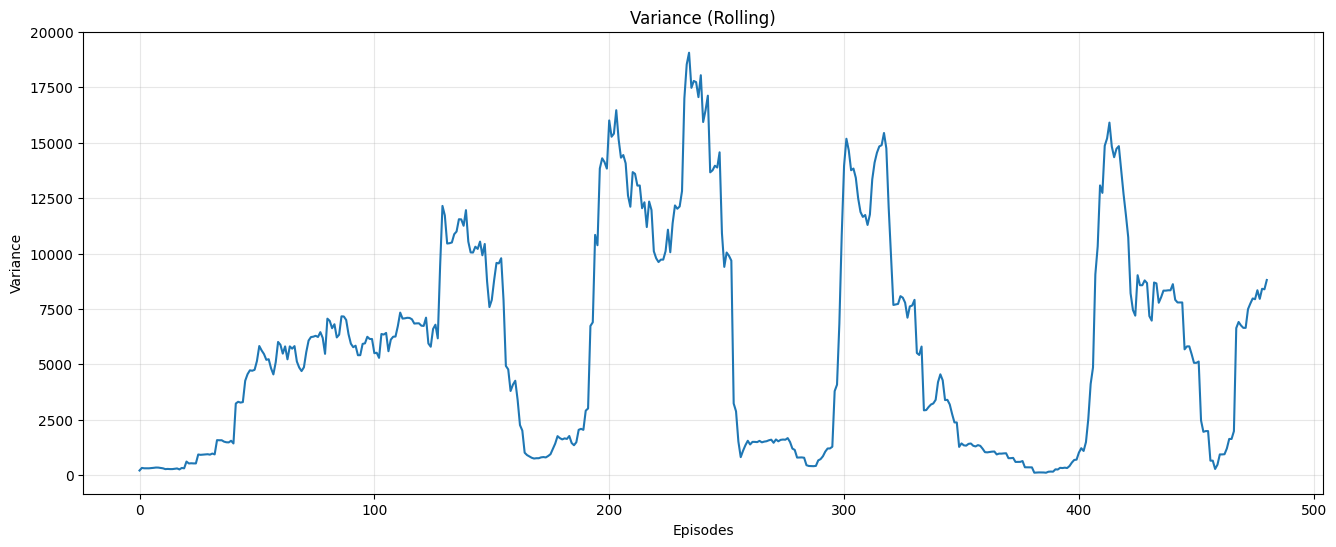

In [32]:
plt.figure(figsize=(16,6))
plot_variance_single_train(results_baseline[0], label="REINFORCE")

## Multi-seed Experiment Plots

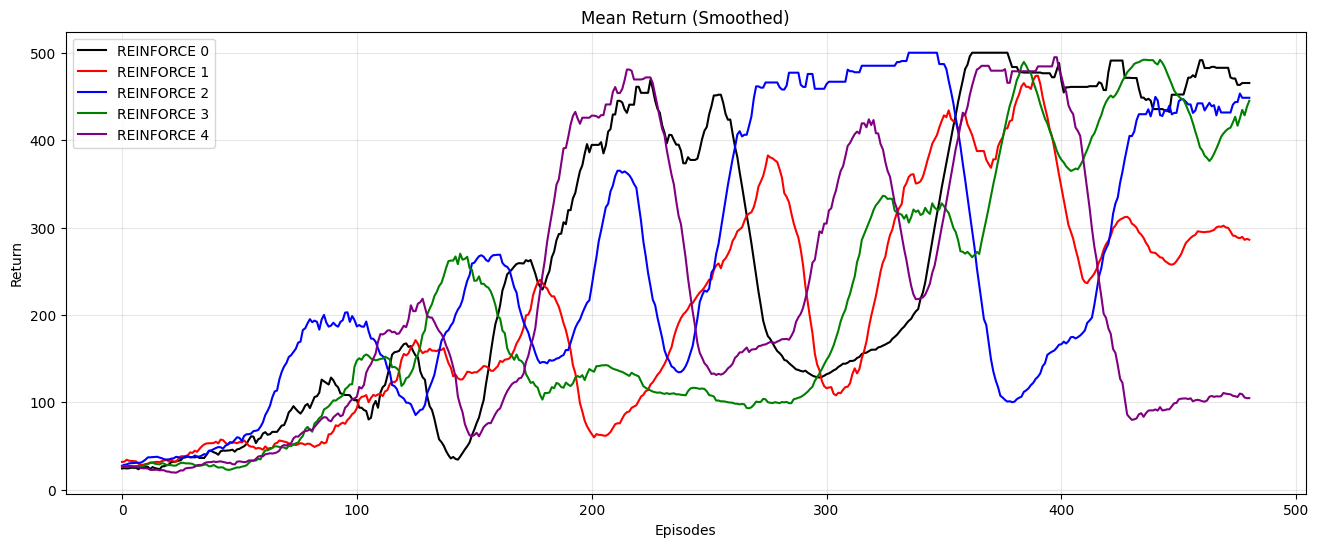

In [33]:
# Mean Returns Plot
plt.figure(figsize=(16,6))
colors = ['black', 'red', 'blue', 'green', 'purple']

for i in range(5):
    plot_mean_return_single_train(
        results_reinforce[i],
        label=f"REINFORCE {i}",
        color=colors[i]
    )

plt.legend()
plt.show()

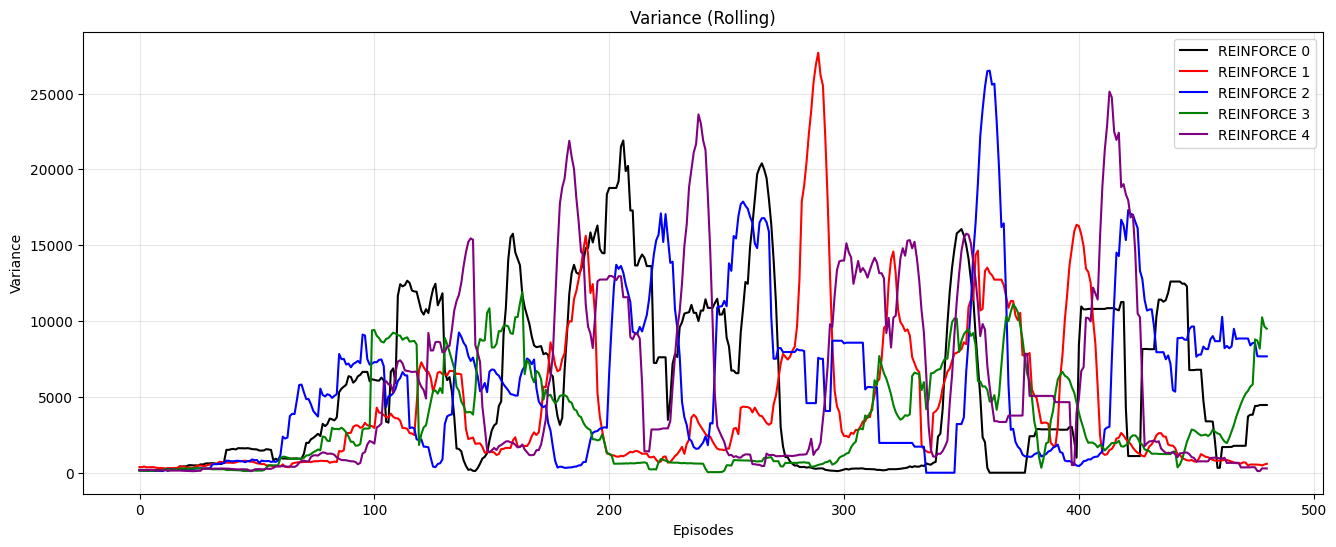

In [34]:
# Variance of Returns Plot
plt.figure(figsize=(16,6))
colors = ['black', 'red', 'blue', 'green', 'purple']

for i in range(5):
    plot_variance_single_train(
        results_reinforce[i],
        label=f"REINFORCE {i}",
        color=colors[i]
    )

plt.legend()
plt.show()